In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# S02 — A flight model is a hypothesis to test

Read the matching lesson before running. Predictions first; source facts, manufactured controls and interpretations are labeled separately. This is not a sports performance benchmark.

In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
from dataclasses import asdict
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/shape_lab').exists())
sys.path.insert(0, str(ROOT / 'src'))
from shape_lab import sports_v8 as sport
from shape_lab.persistence import finite_bottleneck
spl, profiles = sport.load_sports(ROOT)
frames = np.array([r['frame'] for r in spl['records']])
times = sport.frame_times(frames, spl['sampling_rate'])
ball = sport.to_metres([r['ball'] for r in spl['records']], spl['xyz_unit'])
report_dir = ROOT / 'reports/v8/sports'
report_dir.mkdir(parents=True, exist_ok=True)
def save_report(stage, result):
    # Reports contain ordinary finite values; absent values are recorded explicitly.
    (report_dir / f'{stage}.json').write_text(json.dumps(result, indent=2, allow_nan=False) + '\n')
print('Data:', len(frames), 'selected frames from one shot;', len(profiles), 'profiles from', profiles.player_id.nunique(), 'players')


Data: 12 selected frames from one shot; 12 profiles from 8 players


## Recover a manufactured known answer

In [3]:
t=np.arange(8)/10
z=2+4*t-.5*9.81*t*t
control=sport.fit_vertical(t,z)
assert abs(control.g-9.81)<1e-10
assert abs(control.v0-4)<1e-10
print(asdict(control))


{'t0': 0.0, 'z0': 1.9999999999999984, 'v0': 4.000000000000007, 'g': 9.810000000000016, 'residual_rmse_m': 7.570711667007543e-16, 'fit_rows': 8, 'fixed_gravity': False}


## Explicit fitting and later-point groups from one selected shot

In [4]:
fit_mask=(frames>=110)&(frames<=130)
later_mask=np.isin(frames,[135,140])
fixed=sport.fit_vertical(times[fit_mask],ball[fit_mask,2],gravity=9.81)
free=sport.fit_vertical(times[fit_mask],ball[fit_mask,2])
last_height=float(ball[fit_mask,2][-1])
truth=ball[later_mask,2]
predictions={'constant_height':np.full(len(truth),last_height),'fixed_gravity':fixed.predict(times[later_mask]),'free_quadratic':free.predict(times[later_mask])}
mae={k:float(np.mean(abs(v-truth))) for k,v in predictions.items()}
print('Later-point absolute errors (m):',mae)
print('Free fitted curvature parameter g:',free.g,'m/s²; NOT a certified physical measurement')
display(pd.DataFrame({'frame':frames[later_mask], 'source_height_m':truth, **predictions}))


Later-point absolute errors (m): {'constant_height': 0.0446230812746351, 'fixed_gravity': 0.048812474188422605, 'free_quadratic': 0.04466141741406138}
Free fitted curvature parameter g: 12.373855312525205 m/s²; NOT a certified physical measurement


,frame,source_height_m,constant_height,fixed_gravity,free_quadratic
0,135,4.005590,4.013609,4.043214,3.980898
1,140,3.932383,4.013609,3.992383,3.867751


## A plot that reveals both fitting and later observations

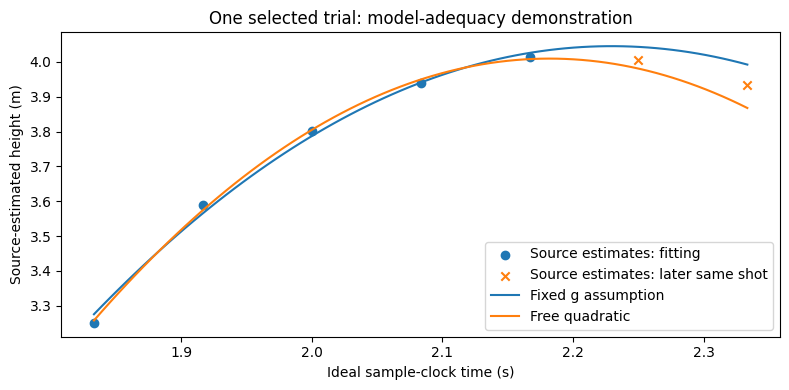

In [5]:
grid=np.linspace(times[fit_mask].min(),times[later_mask].max(),80)
fig,ax=plt.subplots(figsize=(8,4));ax.scatter(times[fit_mask],ball[fit_mask,2],label='Source estimates: fitting')
ax.scatter(times[later_mask],truth,marker='x',label='Source estimates: later same shot')
ax.plot(grid,fixed.predict(grid),label='Fixed g assumption');ax.plot(grid,free.predict(grid),label='Free quadratic')
ax.set(xlabel='Ideal sample-clock time (s)',ylabel='Source-estimated height (m)',title='One selected trial: model-adequacy demonstration')
ax.legend();fig.tight_layout();plt.show()


## Clock ambiguity despite a good curve fit

In [6]:
wrong=sport.fit_vertical(times[fit_mask]*2,ball[fit_mask,2])
assert np.isclose(wrong.g,free.g/4)
save_report('S02',{'fit_frames':frames[fit_mask].tolist(),'later_frames':frames[later_mask].tolist(),'fixed':asdict(fixed),'free':asdict(free),'later_mae_m':mae,'g_with_doubled_clock':wrong.g,'later_points_are_independent_athletes':False,'release_label_known':False})


## Independent explanation
State the observation unit, assumptions, units, one result and one unsupported conclusion. Then work the separate learner notebook without the answer notebook open.